# Метрики классификации

Мы уже знаем с вами о метриках регрессии. Однако недавно мы говорили о линейной классификации (а именно о модели `LogisticRegression`), давайте сначала немного обсудим какие бывают метрики классификации:

## Матрица ошибок. Двухклассовая классификация

Изначально поговорим о том, какие вообще ответы у нас могут быть в случае бин. классификации. Вернее какие варианты работы модели $a$:

Исторически задача бинарной классификации — это задача об обнаружении чего-то редкого в большом потоке объектов.

Например, поиск больного туберкулёзом по флюорографии. Или задача признания пятна на экране приёмника радиолокационной станции бомбардировщиком, представляющим угрозу охраняемому объекту (в противовес стае гусей).

Поэтому класс, который представляет для нас интерес, называется положительным, а оставшийся — отрицательным.

Заметим, что для каждого объекта в выборке возможны четыре ситуации:

1. Мы предсказали положительную метку и угадали. Будем относить такие объекты к группе **TP** (true positive). True — потому что предсказали мы правильно, а positive — потому что предсказали положительную метку.
2. Мы предсказали положительную метку, но ошиблись в своём предсказании — **FP** (false positive). False, потому что предсказание было неправильным.
3. Мы предсказали отрицательную метку и угадали — **TN** (true negative).
Наконец, мы предсказали отрицательную метку, но ошиблись — **FN** (false negative).
4. Для удобства все эти четыре числа изображают в виде таблицы, которую называют матрицей ошибок (англ. confusion matrix):

![alt](../data/confmat.webp)


Не волнуйтесь, если первое время эти обозначения будут сводить вас с ума (будем откровенны, даже профи со стажем в них порой путаются), однако логика за ними достаточно простая: первая часть названия группы показывает, угадали ли мы с классом, а вторая — какой класс мы предсказали.


- $TP$ = кол-во пар, где: $y_{predicted} = 1$, $y_{real} = 1$
- $FP$ = кол-во пар, где: $y_{predicted} = 1$, $y_{real} = 0$ (ошибки первого рода)
- $TN$ = кол-во пар, где: $y_{predicted} = 0$, $y_{real} = 0$
- $FN$ = кол-во пар, где: $y_{predicted} = 0$, $y_{real} = 1$ (ошибки второго рода)

Первая буква - совпадает ли реальность с классификацией. Вторая - Что выдал классификатор.


Источник: [Учебник ШАД](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii#funkciya-poter-metrika-kachestva)

Давайте теперь поговорим о конкретных метриках. Нужно помнить, что `TP`, `TN`, `FP` и `FN` выступают в роли базисных слагаемых для вычисления более сложных (иногда не очень) метрик

## Accuracy

Метрика accuracy характеризует качество модели, агрегированное по всем классам, что полезно, когда классы для нас имеют одинаковое значение. 

$$accuracy = ACC = \frac{TP + TN}{TP + TN + FP + FN}$$

`Важно:` $Accuracy$ может быть обманчивой и полностью несостоятельной метрикой при дисбалансе классов:

Рассмотрим ситуацию, когда положительный класс — это событие редкое. Возьмём в качестве примера поисковую систему: в нашем хранилище есть миллиарды документов, а релевантных к конкретному поисковому запросу на несколько порядков меньше.

Пусть мы хотим решить задачу бинарной классификации «документ $d$ релевантен по запросу $q$». 

Благодаря большому дисбалансу $Accuracy$ классификатора, объявляющего все документы нерелевантными, будет близка к единице. 

и в нашем случае высокое значение метрики будет обеспечено $TN$, в то время как для пользователей более важен высокий $TP$.

## Precision

**Precision (Точность)** отвечает на вопрос: "Какую долю объектов, **предсказанных** моделью как положительный класс, составляют **действительно** объекты положительного класса?".

Формула:
$$precision = P = \frac{TP}{TP + FP}$$

Эта метрика важна, когда цена ложноположительного срабатывания (False Positive) высока.
*   **Пример 1 (Спам-фильтр):** Если мы хотим минимизировать ситуацию, когда важное письмо (не спам) попадает в спам (ложное срабатывание), нам важна высокая precision. Нам лучше не пометить несколько спам-писем (пропустить их), чем удалить важное письмо.
*   **Пример 2 (Поиск релевантных документов):** Мы хотим, чтобы среди всех документов, которые поисковик выдал нам по запросу, было как можно меньше мусора (нерелевантных документов).

## Recall

**Recall (Полнота)** отвечает на вопрос: "Какую долю от **всех реальных** объектов положительного класса модель смогла **обнаружить** (предсказать как положительные)?".

Формула:
$$recall = R = \frac{TP}{TP + FN}$$

Эта метрика важна, когда цена ложноотрицательного срабатывания (False Negative) высока.
*   **Пример 1 (Диагностика рака):** Нам нужно обнаружить болезнь у всех больных. Пропустить больного (False Negative) — значит не начать лечение вовремя, что может стоить жизни. Здесь recall критически важен. Лучше отправить здорового человека на дополнительные обследования (FP), чем пропустить больного (FN).
*   **Пример 2 (Поиск релевантных документов):** Мы хотим, чтобы поисковая система нашла **все** релевантные документы по запросу, даже если среди них попадется немного мусора.

## $F_1$-мера

Часто нам нужно найти баланс между Precision и Recall. Эти метрики находятся в противоречии: увеличивая одну, мы часто уменьшаем другую.

**F₁-мера** — это среднее гармоническое Precision и Recall. Она показывает, насколько хорошо модель одновременно точна и полна.

Формула:
$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

Почему именно среднее гармоническое? Оно "штрафует" модель сильнее, если одна из метрик очень мала. Например, если precision=1.0, а recall=0.0, то среднее арифметическое будет 0.5, что может ввести в заблуждение. F₁ же будет равен 0, что правильно отражает неспособность модели обнаруживать объекты.

## $F_\beta$-мера

$F_\beta$-мера — это обобщение $F_1$, которое позволяет нам гибко настраивать важность precision и recall.

Формула:
$$F_\beta = (1 + \beta^2) \cdot \frac{Precision \cdot Recall}{\beta^2 \cdot Precision + Recall}$$

Коэффициент $\beta$ показывает, во сколько раз recall важнее precision:
*   Если $\beta = 1$: Это $F_1$-мера, баланс.
*   Если $\beta > 1$: Recall важнее. (Например, $F_2$: recall важен в 2 раза больше).
*   Если $\beta < 1$: Precision важнее. (Например, $F_\frac{1}{2}$: precision важен в 2 раза больше).

In [1]:
# Пример расчета precision, recall, F1 на игрушечных данных
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

# Истинные метки (y_true) и предсказания модели (y_pred)
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 0, 1, 1, 0]

# Расчет метрик
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

# Для наглядности построим матрицу ошибок
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

Precision: 0.800
Recall:    0.800
F1-score:  0.800

Confusion Matrix:
[[4 1]
 [1 4]]


## AUC

**Важное уточнение:** Часто под AUC подразумевают именно **ROC-AUC**. Хотя AUC (Area Under Curve) может относиться к площади под любой кривой (например, Precision-Recall кривой), в контексте классификации "AUC" по умолчанию означает площадь под ROC-кривой. Мы сейчас разберем их обе, но важно знать этот нюанс.

### AUC-ROC (Area Under the Receiver Operating Characteristic curve)

ROC-кривая показывает зависимость **True Positive Rate (TPR = Recall)** от **False Positive Rate (FPR)** при изменении порога классификации.

$$TPR = \frac{TP}{TP + FN} = Recall$$
$$FPR = \frac{FP}{FP + TN}$$

*   **TPR:** доля правильно предсказанных положительных объектов (чем больше, тем лучше).
*   **FPR:** доля отрицательных объектов, ошибочно предсказанных как положительные (чем меньше, тем лучше).

AUC-ROC — это площадь под ROC-кривой. Она измеряет, насколько хорошо модель разделяет два класса. Чем AUC-ROC ближе к 1, тем лучше. Значение 0.5 означает, что модель работает не лучше случайного угадывания.

**Интерпретация:** AUC-ROC показывает вероятность того, что случайно выбранный положительный объект будет иметь более высокий "score" (вероятность принадлежности к классу 1), чем случайно выбранный отрицательный объект.

## ROC-AUC

Итак, **ROC-AUC** — это стандартная метрика качества бинарной классификации, которая не зависит от выбранного порога.

[Тут немного анимации](https://mlu-explain.github.io/roc-auc/)

### AUC-PR (Area Under the Precision-Recall curve)

Когда классы сильно несбалансированы (положительный класс очень редок), ROC-AUC может давать чересчур оптимистичную оценку. Это происходит потому, что FPR (знаменатель которого — TN + FP) может оставаться низким просто из-за огромного количества TN.

В таких случаях лучше использовать **AUC-PR** (площадь под кривой Precision-Recall). PR-кривая показывает зависимость Precision от Recall при изменении порога. Она более чувствительна к ошибкам на редком положительном классе.

**Вывод:**
*   Для **сбалансированных** данных хорошо подходит ROC-AUC.
*   Для **сильно несбалансированных** данных предпочтительнее использовать AUC-PR.

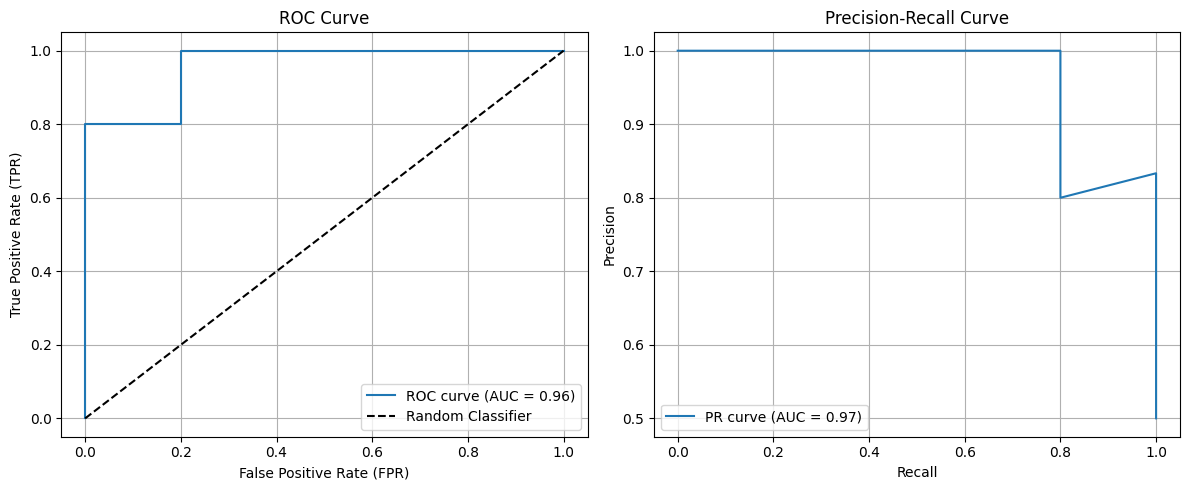

ROC-AUC: 0.960
PR-AUC:  0.967


In [2]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Возьмем те же данные, но добавим вероятности предсказания (scores)
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_scores = [0.9, 0.1, 0.8, 0.4, 0.3, 0.7, 0.2, 0.6, 0.95, 0.15]

# 1. ROC-AUC
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 2. PR-AUC (используем average_precision_score, который вычисляет площадь под PR-кривой)
pr_auc = average_precision_score(y_true, y_scores)

# Построим графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_scores)
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC:  {pr_auc:.3f}")

## Многоклассовая классификация

Когда классов становится больше двух (например, распознавание цифр от 0 до 9), метрики нужно обобщить. Основные подходы:

1.  **Матрица ошибок:** Строится матрица размера $K \times K$, где $K$ — число классов. На пересечении $i$-й строки и $j$-го столбца стоит количество объектов класса $i$, которые были предсказаны как класс $j$.

2.  **Accuracy:** Остается прежней — доля правильных ответов.

3.  **Micro, Macro и Weighted averaging для Precision, Recall, F1:**

    *   **Micro-average (Микро-усреднение):** Мы суммируем все TP, FP, FN по всем классам и затем вычисляем метрику.
        $$Precision_{micro} = \frac{TP_1 + ... + TP_K}{(TP_1+...+TP_K) + (FP_1+...+FP_K)}$$
        По сути, это то же самое, что и accuracy для многоклассовой задачи. Учитывает вклад каждого объекта.

    *   **Macro-average (Макро-усреднение):** Мы вычисляем метрику (например, precision) для каждого класса независимо, а затем берем их среднее арифметическое.
        $$Precision_{macro} = \frac{Precision_1 + Precision_2 + ... + Precision_K}{K}$$
        Здесь каждый класс имеет одинаковый вес, независимо от его размера. Полезно, если все классы одинаково важны.

    *   **Weighted-average (Взвешенное усреднение):** То же, что и macro, но среднее берется с учетом количества объектов в каждом классе (поддержки, support). Это решает проблему дисбаланса классов, когда мы не хотим, чтобы маленький класс влиял на метрику так же сильно, как и большой.

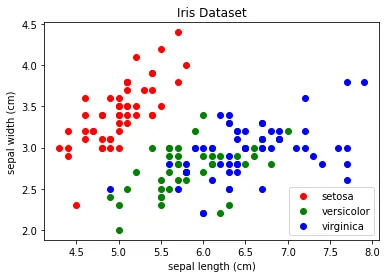

Confusion Matrix (Multiclass):
[[3 0 0]
 [1 2 1]
 [0 1 2]]


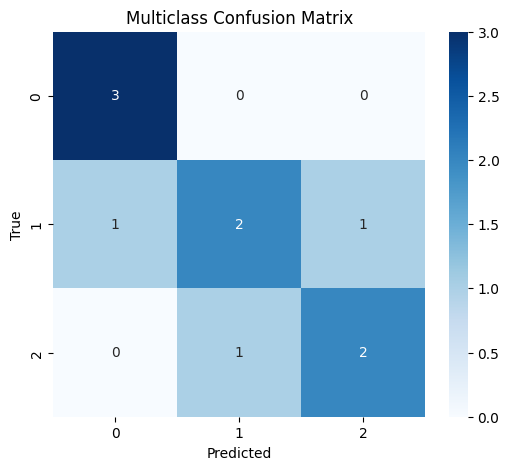


Classification Report:
              precision    recall  f1-score   support

           0      0.750     1.000     0.857         3
           1      0.667     0.500     0.571         4
           2      0.667     0.667     0.667         3

    accuracy                          0.700        10
   macro avg      0.694     0.722     0.698        10
weighted avg      0.692     0.700     0.686        10



In [3]:
# Пример многоклассовой классификации
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Игрушечные данные для 3 классов
y_true_multiclass = [0, 1, 2, 0, 1, 2, 0, 2, 1, 1]
y_pred_multiclass = [0, 0, 2, 0, 1, 2, 0, 1, 1, 2]

# 1. Матрица ошибок
cm_multiclass = confusion_matrix(y_true_multiclass, y_pred_multiclass)
print("Confusion Matrix (Multiclass):")
print(cm_multiclass)

# Визуализация
plt.figure(figsize=(6,5))
sns.heatmap(cm_multiclass, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Multiclass Confusion Matrix')
plt.show()

# 2. Classification report (показывает precision, recall, f1 для каждого класса,
#    а также их micro, macro и weighted средние)
print("\nClassification Report:")
print(classification_report(y_true_multiclass, y_pred_multiclass, digits=3))

# ОФФТОП: Линейный классификатор = Персептрон

![alttext](../data/Neuron.png)

Вы уже знакомы с линейной регрессией $y = w^Tx + b$. Логично спросить, а как сделать так, чтобы эта модель могла классифицировать?
Но и на этот вопрос вы знаете ответ: нужно добавить аппроксимирующую функцию или указать порог классификации.

Однако в 40-х и 50-х годах активно развивалась идея МакКалока и Питтса из области кибернетики

Идея **персептрона**, предложенная Фрэнком Розенблаттом в 1957 году, гениально проста:

1.  Мы берем нашу линейную комбинацию признаков: $z = w^Tx + b$.
2.  Мы пропускаем это значение через **пороговую функцию активации** (или функцию Хевисайда).

$$\hat{y} = \begin{cases} 1, & \text{если } z \ge 0 \\ 0, & \text{если } z < 0 \end{cases}$$

Таким образом, персептрон — это простейшая искусственная нейронная сеть, которая проводит разделяющую плоскость (гиперплоскость) в пространстве признаков. Все объекты, попадающие по одну сторону плоскости, относятся к классу 1, по другую — к классу 0.

**Связь с логистической регрессией:**
В логистической регрессии вместо жесткой пороговой функции мы используем **сигмоиду** $\sigma(z) = \frac{1}{1+e^{-z}}$. Это дает нам на выходе не метку класса, а **вероятность** принадлежности к классу 1. Благодаря этому мы можем не только классифицировать, но и оценивать уверенность модели, а также использовать более мощные методы оптимизации (например, градиентный спуск), так как сигмоида — гладкая функция.

Таким образом, логистическую регрессию можно рассматривать как "смягченную" и более продвинутую версию персептрона.

А вот, кстати, сами отцы-основатели идеи "Искуственного нейрона" (фото сгенерировано в нейронке):

![alt](../data/mp.jpg)

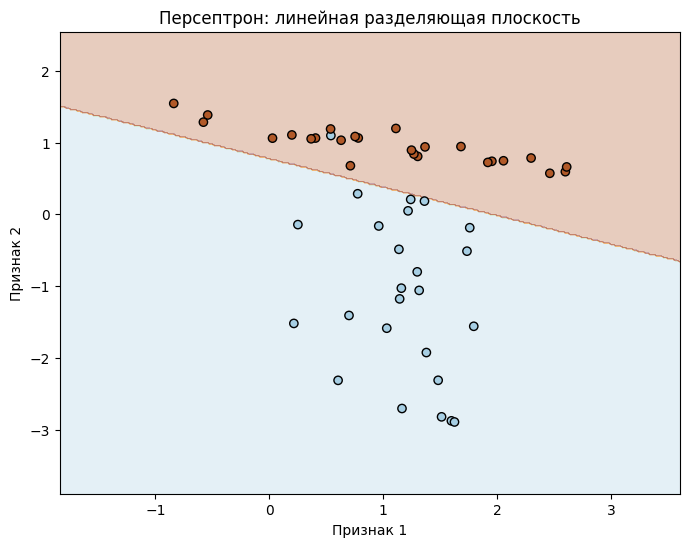

In [4]:
# Визуализация идеи персептрона
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.datasets import make_classification

# Создадим простой набор данных
X, y = make_classification(n_samples=50, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# Обучим персептрон
clf = Perceptron()
clf.fit(X, y)

# Функция для отрисовки разделяющей линии
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)

plt.figure(figsize=(8, 6))
plot_decision_boundary(X, y, clf)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.title('Персептрон: линейная разделяющая плоскость')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

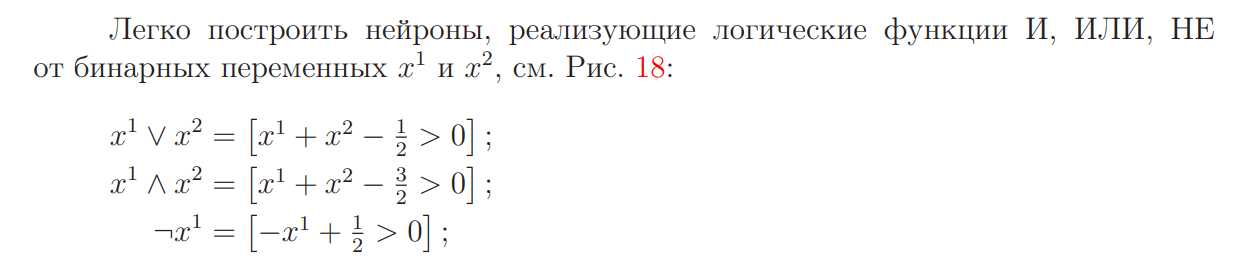

# Регуляризация на практике

Мы знаем, что модель может переобучаться, пытаясь идеально подстроиться под данные, включая шум. Регуляризация — это способ "наказать" модель за слишком сложные решения (большие веса $w$), заставив ее искать более простое и обобщающее решение.

Вспомним функцию потерь для логистической регрессии (Log Loss). Регуляризация добавляет к ней штрафное слагаемое:

$$L(w) = \text{LogLoss}(w) + \lambda \cdot R(w)$$

где $\lambda$ — гиперпараметр, регуляризации, контролирующий силу штрафа.

На практике в `sklearn` мы управляем не $\lambda$ напрямую, а параметром `C`, который является **обратной** величиной силы регуляризации: $C = \frac{1}{\lambda}$.
*   **Маленькое `C`** (например, 0.001) -> **большая** сила регуляризации (стремимся к простой модели).
*   **Большое `C`** (например, 100) -> **маленькая** сила регуляризации (стремимся к сложной модели, можем переобучиться).
*   `C = 1.0` — значение по умолчанию.

## L2, L1, ElasticNet

Давайте разберем основные типы регуляризации, которые можно применить к линейным моделям (на примере `LogisticRegression`):

1.  **L2 регуляризация (Ridge):**
    *   **Штраф:** $R(w) = \frac{1}{2} \sum_{j=1}^{n} w_j^2 = \frac{1}{2} ||w||_2^2$.
    *   **Суть:** Штрафует квадраты весов. Заставляет веса быть равномерно маленькими, но не обнуляет их полностью.
    *   **Эффект:** Хорошо работает, когда много признаков, которые хоть немного, но влияют на результат. Устойчива к мультиколлинеарности.
    *   **В sklearn:** `LogisticRegression(penalty='l2', C=1.0)`

2.  **L1 регуляризация (Lasso):**
    *   **Штраф:** $R(w) = \sum_{j=1}^{n} |w_j| = ||w||_1$.
    *   **Суть:** Штрафует абсолютные значения весов. Способна обнулять веса неинформативных признаков.
    *   **Эффект:** Используется для **отбора признаков (feature selection)**. Модель становится более интерпретируемой, так как оставляет только самые важные признаки.
    *   **В sklearn:** `LogisticRegression(penalty='l1', C=1.0, solver='saga')` (требуется специальный solver).

3.  **ElasticNet:**
    *   **Штраф:** $R(w) = \rho \cdot ||w||_1 + \frac{1-\rho}{2} \cdot ||w||_2^2$.
    *   **Суть:** Комбинация L1 и L2 регуляризации. Параметр `l1_ratio` (`ρ`) контролирует соотношение между ними. Если `l1_ratio=1` — это чистая L1, если `l1_ratio=0` — чистая L2.
    *   **Эффект:** Позволяет сочетать отбор признаков (L1) со сглаживанием весов (L2). Особенно полезна, когда признаки коррелируют между собой.
    *   **В sklearn:** `LogisticRegression(penalty='elasticnet', C=1.0, solver='saga', l1_ratio=0.5)`


`solver='saga'` - это алгоритм оптимизации, используемый совместно с `L1` и `ElasticNet` (**вопрос:** почему для `L2` он не нужен?)


## Пример решения задачи с регуляризацией

Рассмотрим задачу классификации на известном наборе данных `load_wine` (вина Италии). У нас есть 13 признаков (химический состав вина) и 3 целевых класса (сорта вин). Мы увидим, как регуляризация и подбор параметра `C` влияют на качество и веса модели.

In [3]:
# 1.1 Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns

%matplotlib inline

In [5]:
# 1.2 Загрузка и первичный анализ данных
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print("Размерность данных:", X.shape)
print("Признаки:", feature_names)
print("Классы:", target_names)
print("Распределение классов:", np.bincount(y))

Размерность данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Классы: ['class_0' 'class_1' 'class_2']
Распределение классов: [59 71 48]


In [6]:
# 1.3 Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)
print("Распределение классов в train:", np.bincount(y_train))
print("Распределение классов в test:", np.bincount(y_test))

Обучающая выборка: (124, 13)
Тестовая выборка: (54, 13)
Распределение классов в train: [41 50 33]
Распределение классов в test: [18 21 15]


In [7]:
# 1.4 Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Среднее после масштабирования:", X_train_scaled.mean(axis=0).round(2))
print("Стд после масштабирования:", X_train_scaled.std(axis=0).round(2))

Среднее после масштабирования: [ 0.  0.  0.  0. -0.  0.  0. -0.  0. -0.  0.  0. -0.]
Стд после масштабирования: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Доля правильных ответов базовой модели: 0.9815

Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



c:\Users\79222\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


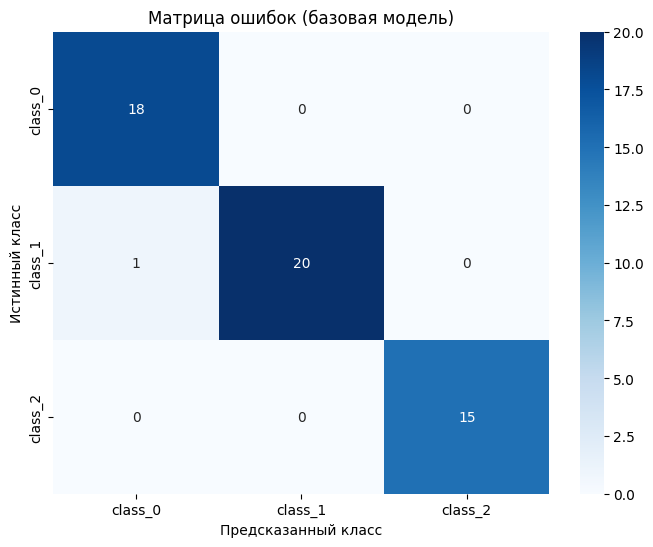

In [8]:
# 1.5 Базовая модель (Baseline) с L2-регуляризацией
model_default = LogisticRegression(penalty='l2', C=1.0, multi_class='ovr', max_iter=10000)
model_default.fit(X_train_scaled, y_train)

y_pred_default = model_default.predict(X_test_scaled)
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"Доля правильных ответов базовой модели: {accuracy_default:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=target_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (базовая модель)')
plt.show()

А теперь немного поработайте исследователями: выполните пункты 2.1 и 2.2 самостоятельно, и запустите пункты 2.3 и 2.4
Вам нужно выполнить немного нетрудных задач, по аналогии с ячейкой выше.

In [ ]:
# Задание 2.1: Исследование влияния параметра C
# TODO: Создайте список значений C для эксперимента со значениями 0.001, 0.01, 1, 100
Cs = [...]  # Коэффициенты регуляризации
coeffs = []
accuracies = []

for C in Cs:
    # TODO: Создайте модель с L2-регуляризацией и текущим C
    model = LogisticRegression(...)

    # TODO: Обучите модель на масштабированных обучающих данных
    model.fit(...)

    # TODO: Сохраните коэффициенты для первого класса
    coeffs.append(...)

    # TODO: Сделайте предсказания на тестовых данных и сохраните точность
    y_pred = ...
    accuracies.append(...)

# TODO: Создайте DataFrame для сравнения весов
coeffs_df = pd.DataFrame(...)
print("Коэффициенты при разных C:")
print(coeffs_df)

# TODO: Визуализируйте веса (создайте subplot для каждого C)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, C in enumerate(Cs):
    axes[i].barh(...)
    axes[i].set_title(f'C={C}')
    axes[i].set_xlabel('Вес признака')
plt.tight_layout()
plt.show()

# TODO: Выведите точность для каждого C
for C, acc in zip(Cs, accuracies):
    print(f"...")

In [ ]:
# Задание 2.2: Сравнение типов регуляризации
results = {}

# TODO: Обучите модель с L2 регуляризацией
model_l2 = LogisticRegression(_____________________________)
model_l2._____________________________
y_pred_l2 = _____________________________
results['L2'] = {
    'accuracy': _____________________________,
    'non_zero': _____________________________
}

# TODO: Обучите модель с L1 регуляризацией (нужен solver='saga')
model_l1 = LogisticRegression(_____________________________)
model_l1._____________________________
y_pred_l1 = _____________________________
results['L1'] = {
    'accuracy': _____________________________,
    'non_zero': _____________________________
}

# TODO: Обучите модель с ElasticNet (solver='saga', l1_ratio=0.5)
model_en = LogisticRegression(_____________________________)
model_en._____________________________
y_pred_en = _____________________________
results['ElasticNet'] = {
    'accuracy': _____________________________,
    'non_zero': _____________________________
}

# TODO: Создайте DataFrame с результатами
results_df = pd.DataFrame(_____________________________)
print("Сравнение типов регуляризации:")
print(results_df)

In [ ]:
# Задание 2.3: Подбор гиперпараметров с GridSearchCV
param_grid = [
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    {'penalty': ['l1'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['saga']},
    {'penalty': ['elasticnet'], 'C': [0.001, 0.01, 0.1, 1, 10, 100],
     'solver': ['saga'], 'l1_ratio': [0.2, 0.5, 0.8]}
]

model = LogisticRegression(multi_class='ovr', max_iter=10000)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Точность на тесте: {accuracy_best:.4f}")

print("\nClassification Report для лучшей модели:")
print(classification_report(y_test, y_pred_best, target_names=target_names))

In [ ]:
# Задание 2.4: Анализ лучшей модели
mean_coef = np.mean(np.abs(best_model.coef_), axis=0)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_coef
}).sort_values('importance', ascending=False)

print("Топ-5 самых важных признаков:")
print(feature_importance.head(5))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Средний модуль коэффициента')
plt.title('Важность признаков в лучшей модели')
plt.gca().invert_yaxis()
plt.show()

n_zero = np.sum(mean_coef < 0.01)
print(f"Всего признаков: {len(mean_coef)}")
print(f"Признаков с близкими к нулю коэффициентами: {n_zero}")
print(f"Процент обнуленных/сжатых признаков: {n_zero/len(mean_coef)*100:.1f}%")